# Automated promoter library redesign

這本 notebook 從 high-throughput PKL database 選取元件，不進行 de novo sequence generation。每個 element 的 model score 範圍切成五個等寬 bins；v1–v4 分別由 bin 1–4 選取，v5 是鎖定的 consensus，且 v1–v4 必須全部弱於 v5。

Spacer 是例外：`Spacer_v2` 來自 bin 2，`Spacer_v3 = Spacer_v2[:-2] + "TG"`，兩者是同一個 coupled design unit。

每個 design state 都組合成 `5^6 = 15,625` variants，使用固定且最大程度均勻的 64 種 3-bp gaps，再由 CorePromoter clean model 掃描最佳 register。

Validation：

- `shift != 0` 就計入 shifted variant。
- m10 shifted rate 與 m35 shifted rate 都必須 `< 10%`。
- 所有 shifted variants 都必須在 `-2..+2 bp`；任何 `abs(shift) > 2` 都不通過。
- 先最佳化 m10；m10 通過後作為 hard constraint，再最佳化 m35。
- 只有 global validation objective 嚴格改善才接受 replacement。


In [28]:
# === Batch 0: setup and editable design config ===
import importlib
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

import automated_promoter_library_design as r
importlib.reload(r)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# Select the frozen whole/CorePromoter checkpoint used for full-sequence scanning.
CORE_MODEL_VARIANT = "tss_pas"  # "baseline" or "tss_pas"
CORE_MODEL_CHECKPOINTS = {
    "baseline": r.WEIGHTS_DIR / "weights_CorePromoter_clean.pt",
    "tss_pas": r.WEIGHTS_DIR / "weights_CorePromoter_tss_pas.pt",
}
if CORE_MODEL_VARIANT not in CORE_MODEL_CHECKPOINTS:
    raise ValueError(f"Unknown CORE_MODEL_VARIANT: {CORE_MODEL_VARIANT!r}")
CORE_MODEL_CHECKPOINT = CORE_MODEL_CHECKPOINTS[CORE_MODEL_VARIANT]
if not CORE_MODEL_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Missing {CORE_MODEL_VARIANT} checkpoint: {CORE_MODEL_CHECKPOINT}. "
        "Run Model_CorePromoter_TSS_pretrain.ipynb first."
    )

# RUN_MODE = "new": create a new output directory.
# RUN_MODE = "resume": continue an existing directory from its checkpoint/final_elements.
RUN_MODE = "new"  # "new" or "resume"
RESUME_DIR = r.DEFAULT_PARENT_OUT / "automated_redesign_20260716_112038"

if RUN_MODE == "new":
    OUT_DIR = r.DEFAULT_PARENT_OUT / f"automated_redesign_{RUN_STAMP}"
elif RUN_MODE == "resume":
    OUT_DIR = Path(RESUME_DIR)
    if not OUT_DIR.exists():
        raise FileNotFoundError(f"Resume directory does not exist: {OUT_DIR}")
else:
    raise ValueError(f"RUN_MODE must be 'new' or 'resume', not {RUN_MODE!r}")

CACHE_DIR = r.PROJECT_ROOT / "outputs" / "energy_bin_cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Edit these sequences when the locked consensus changes.
CONSENSUS = {
    "UP": "TGGACTGATATATACAAAA",
    "m35": "TTGACA",
    "spacer": "TATGGGGCAAAATGGGG",
    "m10": "TATAAT",
    "DIS": "TTTTATTA",
    "ITS": "CAAAAAAAAG",
}

CONFIG = r.DesignConfig(
    consensus=CONSENSUS,
    bg5="CCCTTTCGTCTTCACACAGCAGCAGTCAGGTAGGGAAGAGACC",
    bg3="GTCGACTCTAGA",
    gap_length=3,
    gap_seed=777,
    random_seed=777,
    n_energy_bins=5,
    # Normalized observed-energy ranges used to create four mutable bins (v1-v4).
    # Tune the lower bound to trade weak-sequence coverage against register stability.
    mutable_energy_fraction_ranges={"m35": (0.0, 1.0), "m10": (0.0, 1.0)},
    max_candidates_per_unit=60,
    max_abs_shift=2,
    max_shift_rate=0.10,
    scan_batch_size=15625,
    require_derived_spacer_in_database=False,
)

USE_CACHE = True
MAX_SOURCE_ROWS = None  # None = use all observed sequences in each PKL

SEARCH_SETTINGS = {
    # This is an additional iteration allowance for each new/resume execution.
    "max_iterations": 100,
    "n_driver_units": 3,
    "probe_candidates_per_unit": 2,
    "pair_beam_width": 6,
    "max_pair_evaluations": 8,
    "max_stalled_iterations": 50,
}

config_filename = "run_config.json" if RUN_MODE == "new" else f"resume_config_{RUN_STAMP}.json"
r.save_run_config(
    OUT_DIR, CONFIG, SEARCH_SETTINGS, DEVICE,
    core_model_checkpoint=CORE_MODEL_CHECKPOINT,
    filename=config_filename,
)
print("Run mode:", RUN_MODE)
print("Project root:", r.PROJECT_ROOT)
print("Device:", DEVICE)
print("Output:", OUT_DIR)
print("Core model variant:", CORE_MODEL_VARIANT)
print("Core model checkpoint:", CORE_MODEL_CHECKPOINT)


Run mode: new
Project root: c:\Users\User\OneDrive\桌面\Claude code\promoter library exp
Device: cuda
Output: c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\outputs\019ec8ae-c0ac-7190-868c-5c4ba74a5396\automated_redesign_20260721_120410
Core model variant: tss_pas
Core model checkpoint: c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\weights\weights_CorePromoter_tss_pas.pt


## Batch 1: load trained models and build five equal-width energy bins

UP/Spacer/DIS/ITS 使用各自已訓練的 element weights。`Model_PL.ipynb` 的 -35/-10 data flow 使用 BPM，因此這兩個元素使用 `-BPM dG` 作為 higher-is-stronger score。不同 element 的分數不可互相比較。

Scored pools 會依 PKL 與 weight/BPM parameter 的檔案 signature 快取；來源或模型更新後會自動重建。


In [29]:
element_models = r.ElementModelBundle(DEVICE)
core_model = r.load_core_model(DEVICE, checkpoint_path=CORE_MODEL_CHECKPOINT)

scored_pools = r.build_scored_pools(
    models=element_models,
    config=CONFIG,
    cache_dir=CACHE_DIR,
    use_cache=USE_CACHE,
    max_source_rows=MAX_SOURCE_ROWS,
)

bin_summary = r.energy_bin_summary(scored_pools, CONFIG, element_models)
bin_summary.to_csv(OUT_DIR / "energy_bin_summary.csv", index=False)
display(bin_summary)


,element,energy_bin,binning_mode,energy_fraction_lower,energy_fraction_upper,energy_lower,energy_upper,n_sequences,n_eligible_below_v5,n_excluded_below_range,n_excluded_above_range,v5_energy
0,UP,1,legacy_full_range,0.00,0.20,-2.686171,-1.640854,2715,2715,0,0,1.108542
1,UP,2,legacy_full_range,0.20,0.40,-1.640854,-0.595537,63825,63825,0,0,1.108542
2,UP,3,legacy_full_range,0.40,0.60,-0.595537,0.449780,97097,97097,0,0,1.108542
3,UP,4,legacy_full_range,0.60,0.80,0.449780,1.495097,13181,11459,0,0,1.108542
4,UP,5,legacy_full_range,0.80,1.00,1.495097,2.540413,764,0,0,0,1.108542
5,m35,1,custom_mutable_range,0.00,0.25,-2.811432,-1.124194,269,269,0,0,3.937519
6,m35,2,custom_mutable_range,0.25,0.50,-1.124194,0.563044,1263,1263,0,0,3.937519
7,m35,3,custom_mutable_range,0.50,0.75,0.563044,2.250282,897,897,0,0,3.937519
8,m35,4,custom_mutable_range,0.75,1.00,2.250282,3.937519,155,154,0,0,3.937519
9,spacer,1,legacy_full_range,0.00,0.20,-3.143559,-1.704385,32020,32020,0,0,4.663456


## Batch 2: construct database-backed design units

這個步驟執行 hard constraints：

- 一般 element 的 v1–v4 必須來自對應 bin 1–4。
- 所有 v1–v4 score 必須低於 locked v5。
- 同一 element 的五條 sequence 不可重複。
- Spacer_v2/v3 必須滿足 coupled rule。
- 任一必要 bin 沒有 eligible sequence 時直接報錯，不跨 bin 補候選。


In [30]:
design_space = r.DesignSpace(
    config=CONFIG,
    models=element_models,
    scored_pools=scored_pools,
)

if RUN_MODE == "resume":
    saved_elements_path = OUT_DIR / "current_elements_checkpoint.csv"
    if not saved_elements_path.exists():
        saved_elements_path = OUT_DIR / "final_elements.csv"
    if not saved_elements_path.exists():
        raise FileNotFoundError(f"No resume elements found in {OUT_DIR}")
    initial_elements = pd.read_csv(saved_elements_path)
    initial_state = design_space.state_from_selected_elements(initial_elements)
    print("Recovered state from:", saved_elements_path)
else:
    initial_state = design_space.initial_state()
    initial_elements = design_space.selected_elements(initial_state)

unit_summary = design_space.candidate_pool_summary()

if RUN_MODE == "new":
    initial_elements.to_csv(OUT_DIR / "initial_elements.csv", index=False)
unit_summary.to_csv(OUT_DIR / "design_unit_candidate_counts.csv", index=False)
display(initial_elements)
display(unit_summary)
print("Candidate pool summary before search:")
print(unit_summary.to_string(index=False))


,element,version,design_unit_id,sequence,energy,energy_bin,selection_mode,locked,in_database
0,DIS,v1,v1,GCCCAGCC,-2.317612,1.0,database_bin,False,True
1,DIS,v2,v2,GAGTCACC,-1.167691,2.0,database_bin,False,True
2,DIS,v3,v3,GTGGCCAG,-0.017991,3.0,database_bin,False,True
3,DIS,v4,v4,GTAGTAAA,1.131608,4.0,database_bin,False,True
4,DIS,v5,locked_v5,TTTTATTA,2.856126,5.0,locked_consensus,True,True
5,ITS,v1,v1,GTCCGCCCGC,-1.132915,1.0,database_bin,False,True
6,ITS,v2,v2,CACAGGTCCC,-0.556000,2.0,database_bin,False,True
7,ITS,v3,v3,CCTTTGTTGC,0.021081,3.0,database_bin,False,True
8,ITS,v4,v4,CTCCATTTAA,0.598162,4.0,database_bin,False,True
9,ITS,v5,locked_v5,CAAAAAAAAG,1.452267,5.0,locked_consensus,True,True


,element,design_unit_id,source_energy_bin,energy_fraction_lower,energy_fraction_upper,energy_lower,energy_upper,n_sequences_in_bin,n_eligible_below_v5,n_source_candidates_examined,n_candidates_in_search_pool,max_candidates_per_unit,source_pool_was_capped,note
0,DIS,v1,1,0.00,0.20,-2.892178,-1.742517,1606,1606,60,60,60,True,standard database-backed unit
1,DIS,v2,2,0.20,0.40,-1.742517,-0.592857,14780,14780,60,60,60,True,standard database-backed unit
2,DIS,v3,3,0.40,0.60,-0.592857,0.556804,24037,24037,60,60,60,True,standard database-backed unit
3,DIS,v4,4,0.60,0.80,0.556804,1.706465,12186,12186,60,60,60,True,standard database-backed unit
4,ITS,v1,1,0.00,0.20,-1.421627,-0.844544,8086,8086,60,60,60,True,standard database-backed unit
5,ITS,v2,2,0.20,0.40,-0.844544,-0.267461,198865,198865,60,60,60,True,standard database-backed unit
6,ITS,v3,3,0.40,0.60,-0.267461,0.309622,511415,511415,60,60,60,True,standard database-backed unit
7,ITS,v4,4,0.60,0.80,0.309622,0.886705,215335,215335,60,60,60,True,standard database-backed unit
8,UP,v1,1,0.00,0.20,-2.686171,-1.640854,2715,2715,60,60,60,True,standard database-backed unit
9,UP,v2,2,0.20,0.40,-1.640854,-0.595537,63825,63825,60,60,60,True,standard database-backed unit


Candidate pool summary before search:
element design_unit_id  source_energy_bin  energy_fraction_lower  energy_fraction_upper  energy_lower  energy_upper  n_sequences_in_bin  n_eligible_below_v5  n_source_candidates_examined  n_candidates_in_search_pool  max_candidates_per_unit  source_pool_was_capped                                                                          note
    DIS             v1                  1                   0.00                   0.20     -2.892178     -1.742517                1606                 1606                            60                           60                       60                    True                                                 standard database-backed unit
    DIS             v2                  2                   0.20                   0.40     -1.742517     -0.592857               14780                14780                            60                           60                       60                    True            

## Batch 3: fixed balanced 3-bp gap assignment and 15,625 assembly

`15,625 = 64 × 244 + 9`，所以無法完全等量。最大程度均勻的固定分配是 55 種 gap 各 244 次、9 種各 245 次。這份 assignment 在所有 replacement 前後保持不變。


In [31]:
saved_gap_path = OUT_DIR / "gap_assignment.csv"
if RUN_MODE == "resume" and saved_gap_path.exists():
    gap_assignment = pd.read_csv(saved_gap_path)
    print("Loaded fixed gap assignment:", saved_gap_path)
else:
    gap_assignment = r.build_balanced_gap_assignment(CONFIG)

initial_variants = r.assemble_library(initial_elements, gap_assignment, CONFIG)

gap_counts = (
    gap_assignment["gap_3bp"]
    .value_counts()
    .rename_axis("gap_3bp")
    .reset_index(name="n_variants")
    .sort_values("gap_3bp")
)
gap_assignment.to_csv(OUT_DIR / "gap_assignment.csv", index=False)
if RUN_MODE == "new":
    initial_variants.to_csv(OUT_DIR / "initial_assembled_15625.csv", index=False)

print("Assembled variants:", f"{len(initial_variants):,}")
print("Gap count distribution:", gap_counts["n_variants"].value_counts().sort_index().to_dict())
display(gap_counts)


Assembled variants: 15,625
Gap count distribution: {244: 55, 245: 9}


,gap_3bp,n_variants
52,AAA,244
47,AAC,244
51,AAG,244
60,AAT,244
24,ACA,244
...,...,...
30,TGT,244
38,TTA,244
57,TTC,244
0,TTG,245


## Batch 4: initial CorePromoter register scan

正式欄位：

```text
m10_shift = observed_m10_start - design_m10_start
m35_shift = observed_m35_start - design_m35_start
spacer_length_shift = observed_spacer_len - design_spacer_len
```

Primary classification 使用 `m10_shift`；m10 通過後，secondary phase 使用 `m35_shift`。掃描同時輸出八個 architecture windows、observed element-role sequences、落在哪些 design regions，以及同一 element model 內的 delta energy。


In [32]:
scanner = r.CorePromoterScanner(
    model=core_model,
    element_models=element_models,
    config=CONFIG,
    device=DEVICE,
)

initial_scan = scanner.scan(initial_variants, annotate_element_energies=True)
initial_summary = r.summarize_validation(initial_scan, CONFIG)
initial_scan.to_csv(OUT_DIR / "initial_scan_15625.csv", index=False)

validation_table = pd.DataFrame([
    {
        "anchor": anchor,
        "shifted_count": initial_summary[f"{anchor}_shifted_count"],
        "shifted_rate": initial_summary[f"{anchor}_shifted_rate"],
        "out_of_range_count": initial_summary[f"{anchor}_out_of_range_count"],
        "max_abs_shift": initial_summary[f"{anchor}_max_abs_shift"],
        "pass": initial_summary[f"{anchor}_validation_pass"],
    }
    for anchor in ("m10", "m35")
])
display(validation_table)
print("Global validation pass:", initial_summary["global_validation_pass"])


c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_{field}"] = values
c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_{field}"] = values
c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044:

,anchor,shifted_count,shifted_rate,out_of_range_count,max_abs_shift,pass
0,m10,8878,0.568192,8395,44,False
1,m35,10000,0.640000,8432,43,False


Global validation pass: False


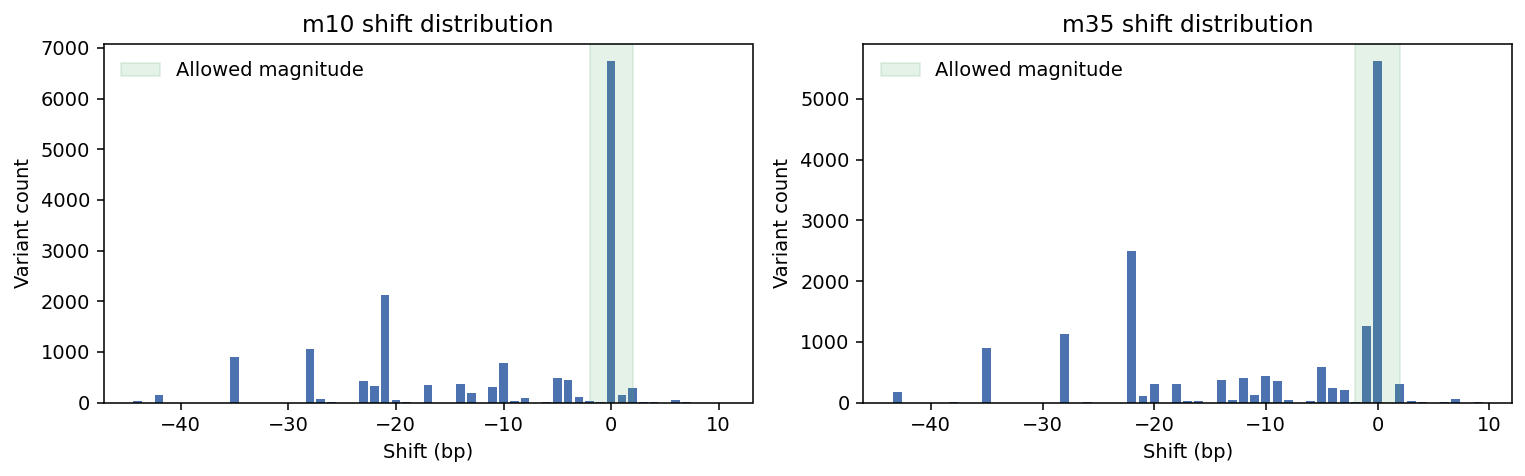

In [33]:
# English-only plot labels for VSCode/Jupyter rendering stability.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), dpi=140)
for ax, anchor in zip(axes, ("m10", "m35")):
    counts = initial_scan[f"{anchor}_shift"].value_counts().sort_index()
    ax.bar(counts.index.astype(int), counts.values, color="#4C72B0")
    ax.axvspan(-2, 2, color="#55A868", alpha=0.15, label="Allowed magnitude")
    ax.set_title(f"{anchor} shift distribution")
    ax.set_xlabel("Shift (bp)")
    ax.set_ylabel("Variant count")
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Batch 5: dominant shift and conditional-risk diagnosis

若目前 phase 仍有 `abs(shift) > 2`，優先診斷 out-of-range variants；否則診斷所有 `shift != 0` variants。先找數量最多的 shift coordinate，再以 `P(dominant shift | element version)` 排名 driver。

Observed role 落在某個 design region 只用來提供 redesign evidence；不同 element model 的 raw delta energy不互相比較。最終 replacement 仍由完整 15,625 before/after validation 決定。


In [34]:
initial_diagnosis = r.diagnose_shift_drivers(
    scan=initial_scan,
    selected_elements=initial_elements,
    design_space=design_space,
    config=CONFIG,
)

print("Optimization phase:", initial_diagnosis["phase"])
print("Dominant shift coordinate:", initial_diagnosis["dominant_shift"])
display(initial_diagnosis["risk"].head(20))
display(initial_diagnosis["overlap"].head(30))


Optimization phase: m10
Dominant shift coordinate: -21


,phase,dominant_shift,element,version,design_unit_id,actionable,n_contexts,n_target_shift,conditional_shift_risk,overall_target_shift_rate,risk_enrichment,top_observed_role_on_design,top_overlap_n,top_overlap_fraction,top_role_median_delta_energy
0,m10,-21,m35,v2,v2,True,3125,1562,0.49984,0.135488,3.689183,spacer,1562,1.0,0.819737
1,m10,-21,spacer,v2,v2_v3_pair,True,3125,826,0.26432,0.135488,1.950874,DIS,826,1.0,1.706628
2,m10,-21,UP,v4,v4,True,3125,809,0.25888,0.135488,1.910723,m35,809,1.0,3.420862
3,m10,-21,spacer,v3,v2_v3_pair,True,3125,716,0.22912,0.135488,1.691072,DIS,716,1.0,1.706628
4,m10,-21,DIS,v1,v1,True,3125,604,0.19328,0.135488,1.426547,UP,0,0.0,NaN
5,m10,-21,UP,v2,v2,True,3125,578,0.18496,0.135488,1.365139,m35,578,1.0,2.993164
6,m10,-21,ITS,v1,v1,True,3125,506,0.16192,0.135488,1.195087,UP,0,0.0,NaN
7,m10,-21,DIS,v2,v2,True,3125,496,0.15872,0.135488,1.171469,UP,0,0.0,NaN
8,m10,-21,m10,v1,v1,True,3125,489,0.15648,0.135488,1.154936,ITS,489,1.0,0.522359
9,m10,-21,m10,v4,v4,True,3125,478,0.15296,0.135488,1.128956,ITS,478,1.0,0.998185


,phase,dominant_shift,design_element,design_version,observed_role,n_target_contexts,overlap_n,overlap_fraction,median_within_model_delta_energy,max_within_model_delta_energy
0,m10,-21,m35,v2,spacer,1562,1562,1.0,0.819737,4.587555
1,m10,-21,m35,v2,m10,1562,1562,1.0,0.202994,3.224692
2,m10,-21,spacer,v2,m10,826,826,1.0,0.202994,3.224692
3,m10,-21,spacer,v2,DIS,826,826,1.0,1.706628,2.856548
4,m10,-21,spacer,v2,ITS,826,826,1.0,0.966755,2.152182
5,m10,-21,UP,v4,m35,809,809,1.0,3.420862,5.112534
6,m10,-21,UP,v4,spacer,809,809,1.0,-0.033317,3.415180
7,m10,-21,spacer,v3,m10,716,716,1.0,0.202994,3.224692
8,m10,-21,spacer,v3,DIS,716,716,1.0,1.706628,2.856548
9,m10,-21,spacer,v3,ITS,716,716,1.0,0.631795,1.785792


## Batch 6: monotonic automated redesign with live progress and resume

每輪會 print iteration、phase、目前 m10/m35 shifted rate、out-of-range count、dominant shift、driver units、每個 proposal 結果與接受/拒絕原因。

執行期間會在 `OUT_DIR` 持續覆寫：

- `search_progress.csv`：每輪狀態的持續更新 DataFrame。
- `proposal_history_checkpoint.csv`：所有已測 single/double proposals。
- `current_elements_checkpoint.csv`：目前接受的 30 條 sequences。
- `current_validation.json`：目前 validation。
- `search_checkpoint.json`：state、最後完成輪數、stalled counter 與已測 proposals。

`progress_df` 也會在記憶體中每輪原地更新；手動 interrupt 後可直接 `display(progress_df.tail())`。

若中途停止 kernel，將 setup cell 的 `RUN_MODE` 改為 `"resume"`，並把 `RESUME_DIR` 指向原本的 output directory；Batch 6 會從下一個 iteration 繼續。每次 resume 的 `max_iterations` 是額外輪數，不是總累積上限。


In [35]:
redesigner = r.AutomatedRedesigner(
    design_space=design_space,
    scanner=scanner,
    gap_assignment=gap_assignment,
    config=CONFIG,
    out_dir=OUT_DIR,
    **SEARCH_SETTINGS,
)

# Mutated in place after every completed iteration. It remains available if
# this cell is manually interrupted.
progress_df = pd.DataFrame()

result = redesigner.run(
    initial_state=initial_state,
    initial_evaluation=(initial_elements, initial_scan, initial_summary),
    resume=(RUN_MODE == "resume"),
    reset_stalled_on_resume=True,
    progress_df=progress_df,
)

proposal_df = result.proposals

print("Success:", result.success)
print("Stop reason:", result.stop_reason)
print("Saved to:", result.out_dir)
display(pd.DataFrame([result.final_summary]))
display(progress_df)



[Iteration 1] phase=m10 | m10 shifted=56.82% out=8395 max_abs=44 | m35 shifted=64.00% out=8432 max_abs=43 | stalled=0/50
  dominant m10_shift=-21 | drivers=['m35:v2', 'spacer:v2_v3_pair', 'UP:v4']
  driver pools: ['m35:v2 remaining=59/59', 'spacer:v2_v3_pair remaining=58/58', 'UP:v4 remaining=59/59']
    evaluating single: m35:v2->1
      m10=54.77% (out=8336) | m35=61.14% (out=8395)
    evaluating single: m35:v2->2
      m10=54.71% (out=8343) | m35=61.25% (out=8384)
    evaluating single: spacer:v2_v3_pair->1
      m10=56.27% (out=8166) | m35=62.81% (out=8202)
    evaluating single: spacer:v2_v3_pair->2
      m10=58.25% (out=8531) | m35=65.13% (out=8547)
    evaluating single: UP:v4->1
      m10=56.86% (out=8369) | m35=63.72% (out=8398)
    evaluating single: UP:v4->2
      m10=55.16% (out=8024) | m35=63.45% (out=8059)
    evaluating double: m35:v2->2;UP:v4->2
      m10=53.29% (out=8088) | m35=60.56% (out=8131)
    evaluating double: m35:v2->2;spacer:v2_v3_pair->1
      m10=54.22% (o

c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_{field}"] = values
c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_{field}"] = values
c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044:

  dominant m10_shift=-28 | drivers=['UP:v2', 'UP:v3', 'm35:v2']
  driver pools: ['UP:v2 remaining=59/59', 'UP:v3 remaining=59/59', 'm35:v2 remaining=59/59']
    evaluating single: UP:v2->1
      m10=52.37% (out=7928) | m35=59.70% (out=7976)
    evaluating single: UP:v2->2
      m10=51.79% (out=7847) | m35=59.46% (out=7887)
    evaluating single: UP:v3->1
      m10=51.96% (out=7825) | m35=59.39% (out=7892)
    evaluating single: UP:v3->2
      m10=52.91% (out=8008) | m35=61.82% (out=8055)
    evaluating single: m35:v2->0
      m10=55.16% (out=8024) | m35=63.45% (out=8059)
    evaluating single: m35:v2->1
      m10=53.53% (out=8113) | m35=60.54% (out=8171)
    evaluating double: UP:v2->2;UP:v3->1
      m10=50.45% (out=7584) | m35=58.29% (out=7648)
    evaluating double: UP:v2->2;UP:v3->2
      m10=51.40% (out=7767) | m35=60.72% (out=7811)
    evaluating double: UP:v2->2;m35:v2->1
      m10=52.56% (out=7959) | m35=59.81% (out=8011)
    evaluating double: UP:v2->2;m35:v2->0
      m10=53.70

c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_{field}"] = values
c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_{field}"] = values
c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044:

  dominant m10_shift=-35 | drivers=['m35:v2', 'spacer:v2_v3_pair', 'm35:v3']
  driver pools: ['m35:v2 remaining=59/59', 'spacer:v2_v3_pair remaining=58/58', 'm35:v3 remaining=59/59']
    evaluating single: m35:v2->0
      m10=52.45% (out=7400) | m35=61.71% (out=7446)
    evaluating single: m35:v2->1
      m10=51.03% (out=7652) | m35=58.85% (out=7739)
    evaluating single: spacer:v2_v3_pair->1
      m10=51.15% (out=7517) | m35=57.53% (out=7568)
    evaluating single: spacer:v2_v3_pair->2
      m10=53.83% (out=8171) | m35=60.76% (out=8211)
    evaluating single: m35:v3->1
      m10=51.06% (out=7663) | m35=54.21% (out=7768)
    evaluating single: m35:v3->2
      m10=51.17% (out=7704) | m35=54.33% (out=7769)
    evaluating double: m35:v2->1;m35:v3->1
      m10=51.64% (out=7731) | m35=54.77% (out=7859)
    evaluating double: m35:v2->1;spacer:v2_v3_pair->1
      m10=51.92% (out=7626) | m35=57.73% (out=7700)
    evaluating double: m35:v2->1;m35:v3->2
      m10=51.76% (out=7772) | m35=54.89% 

...


[Iteration 80] phase=m10 | m10 shifted=26.91% out=4192 max_abs=43 | m35 shifted=48.97% out=4200 max_abs=43 | stalled=0/50
  dominant m10_shift=-35 | drivers=['spacer:v2_v3_pair', 'm35:v1', 'm35:v2']
  driver pools: ['spacer:v2_v3_pair remaining=58/58', 'm35:v1 remaining=59/59', 'm35:v2 remaining=59/59']
    evaluating single: spacer:v2_v3_pair->0
      m10=30.80% (out=4809) | m35=51.94% (out=4810)
    evaluating single: spacer:v2_v3_pair->1
      m10=32.70% (out=5104) | m35=51.80% (out=5104)
    evaluating single: m35:v1->0
      m10=34.29% (out=5229) | m35=48.81% (out=5324)
    evaluating single: m35:v1->1
      m10=30.24% (out=4686) | m35=48.97% (out=4721)
    evaluating single: m35:v2->0
      m10=33.26% (out=5013) | m35=48.76% (out=4996)
    evaluating single: m35:v2->1
      m10=31.35% (out=4845) | m35=44.50% (out=4883)
    evaluating double: m35:v1->1;spacer:v2_v3_pair->0
      m10=33.86% (out=5283) | m35=51.94% (out=5290)
    evaluating double: m35:v1->1;m35:v2->1
      m10=34.

c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_{field}"] = values
c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{name}_{field}"] = values
c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\MS2_Data_PyTorch\scripts\automated_promoter_library_design.py:1044:


[Search stopped] reason=max_iterations_this_run | last_iteration=100 | m10=26.90% | m35=48.99%
Success: False
Stop reason: max_iterations_this_run
Saved to: c:\Users\User\OneDrive\桌面\Claude code\promoter library exp\outputs\019ec8ae-c0ac-7190-868c-5c4ba74a5396\automated_redesign_20260721_120410


,n_variants,max_allowed_shifted_count,target_margin_positive_count,target_margin_positive_rate,target_margin_mean,target_margin_median,target_margin_min,m10_shifted_count,m10_shifted_rate,m10_out_of_range_count,m10_max_abs_shift,m10_validation_pass,m35_shifted_count,m35_shifted_rate,m35_out_of_range_count,m35_max_abs_shift,m35_validation_pass,global_validation_pass,phase
0,15625,1562,7970,0.51008,-0.041553,0.077209,-6.553345,4203,0.268992,4196,43,False,7655,0.48992,4199,43,False,False,m10


,iteration,accepted,changes,n_variants,max_allowed_shifted_count,target_margin_positive_count,target_margin_positive_rate,target_margin_mean,target_margin_median,target_margin_min,...,m10_out_of_range_count,m10_max_abs_shift,m10_validation_pass,m35_shifted_count,m35_shifted_rate,m35_out_of_range_count,m35_max_abs_shift,m35_validation_pass,global_validation_pass,phase
0,0,True,initial,15625,1562,5504,0.352256,-1.106233,-1.190999,-9.296711,...,8395,44,False,10000,0.640000,8432,43,False,False,m10
1,1,True,m35:v2->2;UP:v4->2,15625,1562,6016,0.385024,-0.833644,-0.884297,-8.646240,...,8088,44,False,9463,0.605632,8131,43,False,False,m10
2,2,True,UP:v2->2;UP:v3->1,15625,1562,6352,0.406528,-0.711126,-0.686042,-9.006225,...,7584,43,False,9108,0.582912,7648,43,False,False,m10
3,3,False,no_strict_improvement,15625,1562,6352,0.406528,-0.711126,-0.686042,-9.006225,...,7584,43,False,9108,0.582912,7648,43,False,False,m10
4,4,True,spacer:v2_v3_pair->3;m35:v3->3,15625,1562,7638,0.488832,-0.315884,-0.081726,-8.674804,...,6969,43,False,7848,0.502272,7060,43,False,False,m10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,96,False,no_strict_improvement,15625,1562,7974,0.510336,-0.012115,0.077569,-6.398072,...,4192,43,False,7651,0.489664,4200,43,False,False,m10
97,97,False,no_strict_improvement,15625,1562,7974,0.510336,-0.012115,0.077569,-6.398072,...,4192,43,False,7651,0.489664,4200,43,False,False,m10
98,98,False,no_strict_improvement,15625,1562,7974,0.510336,-0.012115,0.077569,-6.398072,...,4192,43,False,7651,0.489664,4200,43,False,False,m10
99,99,False,no_strict_improvement,15625,1562,7974,0.510336,-0.012115,0.077569,-6.398072,...,4192,43,False,7651,0.489664,4200,43,False,False,m10


## Batch 7: final design and audit tables

`final_elements.csv` 是最後保留的 30 條 element sequences；`proposal_history.csv` 同時保留 accepted 與 rejected moves，方便追蹤為何某次替換沒有被採用。


In [36]:
display(result.final_elements)
display(result.final_risk.head(20))
display(result.final_overlap.head(30))

final_shift_table = pd.DataFrame([
    {
        "anchor": anchor,
        "shifted_count": result.final_summary[f"{anchor}_shifted_count"],
        "shifted_rate": result.final_summary[f"{anchor}_shifted_rate"],
        "out_of_range_count": result.final_summary[f"{anchor}_out_of_range_count"],
        "max_abs_shift": result.final_summary[f"{anchor}_max_abs_shift"],
        "pass": result.final_summary[f"{anchor}_validation_pass"],
    }
    for anchor in ("m10", "m35")
])
display(final_shift_table)

accepted = result.proposals[result.proposals.get("accepted", False) == True] if len(result.proposals) else result.proposals
display(accepted)


,element,version,design_unit_id,sequence,energy,energy_bin,selection_mode,locked,in_database
0,DIS,v1,v1,GCCCAGCC,-2.317612,1.0,database_bin,False,True
1,DIS,v2,v2,GAGTCACC,-1.167691,2.0,database_bin,False,True
2,DIS,v3,v3,GTGGCCAG,-0.017991,3.0,database_bin,False,True
3,DIS,v4,v4,GTAGTAAA,1.131608,4.0,database_bin,False,True
4,DIS,v5,locked_v5,TTTTATTA,2.856126,5.0,locked_consensus,True,True
5,ITS,v1,v1,GTCCGCCCGC,-1.132915,1.0,database_bin,False,True
6,ITS,v2,v2,CACAGGTCCC,-0.556000,2.0,database_bin,False,True
7,ITS,v3,v3,CCTTTGTTGC,0.021081,3.0,database_bin,False,True
8,ITS,v4,v4,CTCCATTTAA,0.598162,4.0,database_bin,False,True
9,ITS,v5,locked_v5,CAAAAAAAAG,1.452267,5.0,locked_consensus,True,True


,phase,dominant_shift,element,version,design_unit_id,actionable,n_contexts,n_target_shift,conditional_shift_risk,overall_target_shift_rate,risk_enrichment,top_observed_role_on_design,top_overlap_n,top_overlap_fraction,top_role_median_delta_energy
0,m10,-18,m35,v1,v1,True,3125,685,0.21920,0.067584,3.243371,m10,685,1.0,2.389672
1,m10,-18,spacer,v2,v2_v3_pair,True,3125,556,0.17792,0.067584,2.632576,m10,556,1.0,2.389672
2,m10,-18,spacer,v3,v2_v3_pair,True,3125,495,0.15840,0.067584,2.343750,m10,495,1.0,2.389672
3,m10,-18,m10,v1,v1,True,3125,361,0.11552,0.067584,1.709280,ITS,361,1.0,-0.682764
4,m10,-18,DIS,v1,v1,True,3125,348,0.11136,0.067584,1.647727,UP,0,0.0,NaN
5,m10,-18,m35,v3,v3,True,3125,332,0.10624,0.067584,1.571970,m10,332,1.0,2.389672
6,m10,-18,m10,v2,v2,True,3125,305,0.09760,0.067584,1.444129,ITS,305,1.0,-0.822023
7,m10,-18,UP,v5,locked_v5,False,3125,304,0.09728,0.067584,1.439394,m35,304,1.0,3.553141
8,m10,-18,ITS,v1,v1,True,3125,303,0.09696,0.067584,1.434659,UP,0,0.0,NaN
9,m10,-18,UP,v3,v3,True,3125,297,0.09504,0.067584,1.406250,m35,297,1.0,2.507718


,phase,dominant_shift,design_element,design_version,observed_role,n_target_contexts,overlap_n,overlap_fraction,median_within_model_delta_energy,max_within_model_delta_energy
0,m10,-18,m35,v1,spacer,685,685,1.0,1.105948,3.143634
1,m10,-18,m35,v1,m10,685,685,1.0,2.389672,3.910465
2,m10,-18,spacer,v2,m10,556,556,1.0,2.389672,3.910465
3,m10,-18,spacer,v2,DIS,556,556,1.0,1.335107,2.485028
4,m10,-18,spacer,v2,ITS,556,556,1.0,-0.229910,1.522430
5,m10,-18,spacer,v3,m10,495,495,1.0,2.389672,3.910465
6,m10,-18,spacer,v3,DIS,495,495,1.0,1.335107,2.485028
7,m10,-18,spacer,v3,ITS,495,495,1.0,-0.349200,1.403139
8,m10,-18,m10,v1,ITS,361,361,1.0,-0.682764,0.471233
9,m10,-18,m35,v3,spacer,332,332,1.0,1.018459,2.519615


,anchor,shifted_count,shifted_rate,out_of_range_count,max_abs_shift,pass
0,m10,4203,0.268992,4196,43,False
1,m35,7655,0.489920,4199,43,False


,iteration,phase,proposal_type,changes,valid,error,accepted,n_variants,max_allowed_shifted_count,target_margin_positive_count,...,m10_out_of_range_count,m10_max_abs_shift,m10_validation_pass,m35_shifted_count,m35_shifted_rate,m35_out_of_range_count,m35_max_abs_shift,m35_validation_pass,global_validation_pass,objective
6,1,m10,double,m35:v2->2;UP:v4->2,True,,True,15625,1562,6016,...,8088,44,False,9463,0.605632,8131,43,False,False,"(8327, 9463, 16219, 44, 43)"
20,2,m10,double,UP:v2->2;UP:v3->1,True,,True,15625,1562,6352,...,7584,43,False,9108,0.582912,7648,43,False,False,"(7883, 9108, 15232, 43, 43)"
48,4,m10,double,spacer:v2_v3_pair->3;m35:v3->3,True,,True,15625,1562,7638,...,6969,43,False,7848,0.502272,7060,43,False,False,"(7264, 7848, 14029, 43, 43)"
59,5,m10,single,m35:v1->2,True,,True,15625,1562,7604,...,6296,43,False,7882,0.504448,6317,43,False,False,"(6498, 7882, 12613, 43, 43)"
87,7,m10,single,m35:v2->4,True,,True,15625,1562,6948,...,6212,43,False,8538,0.546432,6249,43,False,False,"(6404, 8538, 12461, 43, 43)"
160,12,m10,double,m35:v2->10;m35:v1->9,True,,True,15625,1562,6948,...,5957,43,False,8538,0.546432,5966,43,False,False,"(6139, 8538, 11923, 43, 43)"
421,31,m10,single,m35:v2->38,True,,True,15625,1562,6948,...,5840,43,False,8538,0.546432,5851,43,False,False,"(6093, 8538, 11691, 43, 43)"
453,33,m10,single,UP:v4->4,True,,True,15625,1562,6905,...,5836,43,False,8588,0.549632,5844,43,False,False,"(6080, 8588, 11680, 43, 43)"
494,36,m10,single,UP:v4->5,True,,True,15625,1562,6931,...,5811,43,False,8560,0.547840,5819,43,False,False,"(6065, 8560, 11630, 43, 43)"
547,40,m10,single,UP:v4->8,True,,True,15625,1562,6983,...,5578,43,False,8503,0.544192,5586,43,False,False,"(5853, 8503, 11164, 43, 43)"
